# Projeto de Bloco - TP1

**Disciplina:** Projeto de Bloco: Análise e Segurança de Agentes de IA

**Professor:** Tiago Cariolano de Souza Xavier

**Grupo:** Bernardo de Moraes Eleuterio, Felipe Roberto Rocha, Guilherme Valentim Ramalho da Silva e Heitor Cella Oliveira


# 1. Documentação do Dataset

### Fonte (origem do dataset)

- **Nome:** Customer Support Ticket Dataset
- **Autor/Mantenedor no Kaggle:** [suraj520](https://www.kaggle.com/suraj520)
- **Link:** https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset

### Principais características

- Cada linha representa **um chamado (ticket)** aberto por um cliente.
- Contém **8.469 amostras** com **17 colunas**, combinando dados demográficos do cliente, dados do produto, texto livre (descrição do problema) e metadados operacionais do atendimento (canal, prioridade, status, tempos de resposta/resolução, satisfação).
- A coluna **`Ticket Description`** é a coluna de **texto livre** escrita pelo "cliente" descrevendo o problema/solicitação.
- A coluna **`Ticket Type`** é a coluna de **categoria/intenção** do chamado, com 5 valores possíveis: `Technical issue`, `Billing inquiry`, `Cancellation request`, `Product inquiry`, `Refund request`.

### Motivo da escolha do dataset

O dataset foi escolhido por conter milhares de exemplos reais de tickets de suporte, unindo o texto escrito pelo cliente à categoria do problema. Ele oferece exatamente a matéria-prima que o nosso sistema precisa para aprender a ler uma mensagem, identificar a intenção real do usuário (como suporte técnico ou cobrança) e rotear o chamado de forma automática e eficiente.


# 2. Importação de Bibliotecas e Carregamento dos Dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

df = pd.read_csv("customer_support_tickets.csv")

def print_formatado(*args, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * largura_total)
    print(titulo)
    print("=" * largura_total)


# 3. Compreensão do Problema e do Dataset

**Domínio do problema:** o sistema de atendimento ao cliente foi construído para entender a partir de uma mensagem enviada pelo cliente, **qual é a intenção do chamado** (é um problema técnico? uma dúvida sobre cobrança? um pedido de cancelamento? uma dúvida sobre produto? um pedido de reembolso?), para então poder rotear/priorizar o atendimento ou, futuramente, automatizar respostas.

**Exemplo do domínio do problema:**

| Mensagem (`Ticket Description`, resumida) | Intenção esperada (`Ticket Type`) |
|---|---|
| "My {product} is making strange noises and not functioning properly..." | Refund request |
| "I've forgotten my password for my {product} account..." | Technical issue |
| "I'm facing a recurring issue with my {product} where it..." | Cancellation request |

# 4. Inspeção Inicial

In [ ]:
print_formatado("1. Tamanho do dataset:")
print(df.shape)

print_formatado("2. Variáveis do dataset:")
print(df.columns.tolist())

print_formatado("3. Significado das colunas:")
print("Ver célula Markdown a seguir.")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização dos registros:")
df.info()

print_formatado("6. Exemplos de valores:")
print("\nPrimeiros registros:")
display(df.head())

print("\nÚltimos registros:")
display(df.tail())

print("\nRegistros aleatórios:")
display(df.sample(5, random_state=1))

print_formatado("7. Identificação das variáveis")
print("\nVariáveis numéricas:")
print(df[["Customer Age", "Customer Satisfaction Rating"]].describe())

print("\nVariáveis categóricas (quantidade de categorias únicas):")
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender"]
for coluna in colunas_categoricas:
    print(f"{coluna:<20}: {df[coluna].nunique()} categorias -> {df[coluna].unique().tolist()}")

print("\nVariáveis textuais (texto livre, alta cardinalidade):")
for coluna in ["Customer Name", "Customer Email", "Ticket Description", "Resolution"]:
    print(f"{coluna:<20}: {df[coluna].nunique()} valores únicos de {df[coluna].notnull().sum()} não nulos")

print("\nVariáveis temporais (datas/horários em formato texto):")
for coluna in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    print(f"{coluna:<20}: exemplo -> {df[coluna].dropna().iloc[0]}")

print("\nVariável identificadora:")
print(f"Ticket ID: {df['Ticket ID'].nunique()} valores únicos de {len(df)} registros (identificador único, não é feature)")


print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver célula Markdown a seguir.")


print_formatado("9. Possíveis problemas nos dados")
print("Ver célula Markdown a seguir.")




1. Tamanho do dataset:
(8469, 17)


2. Variáveis do dataset:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


3. Significado das colunas:
Ver célula Markdown a seguir.


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Cha

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Últimos registros:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN



Registros aleatórios:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
1825,1826,Angela Humphrey,joshua84@example.com,55,Female,Bose SoundLink Speaker,2021-06-11,Billing inquiry,Hardware issue,I'm having an issue with the {product_purchase...,Closed,Any because size far record.,High,Chat,2023-06-01 17:06:29,2023-06-01 06:25:29,2.0
473,474,James Escobar,huertaryan@example.com,32,Male,Adobe Photoshop,2021-10-08,Technical issue,Hardware issue,I'm having an issue with the {product_purchase...,Open,NaN,Medium,Phone,NaN,NaN,NaN
3509,3510,Daniel Mccullough,davidcox@example.com,61,Male,Adobe Photoshop,2021-02-16,Refund request,Product recommendation,I'm encountering a software bug in the {produc...,Open,NaN,Critical,Chat,NaN,NaN,NaN
5415,5416,Nicole Knight,johnhess@example.com,46,Female,Bose QuietComfort,2020-08-20,Refund request,Software bug,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,High,Chat,2023-06-01 13:49:59,NaN,NaN
5537,5538,Jessica Chase,wschwartz@example.com,45,Female,Samsung Galaxy,2021-02-02,Technical issue,Software bug,I'm having an issue with the {product_purchase...,Closed,Debate wife window kitchen inside tonight give...,Low,Phone,2023-05-31 23:53:47,2023-06-01 13:18:47,2.0




7. Identificação das variáveis

Variáveis numéricas:
       Customer Age  Customer Satisfaction Rating
count   8469.000000                   2769.000000
mean      44.026804                      2.991333
std       15.296112                      1.407016
min       18.000000                      1.000000
25%       31.000000                      2.000000
50%       44.000000                      3.000000
75%       57.000000                      4.000000
max       70.000000                      5.000000

Variáveis categóricas (quantidade de categorias únicas):
Ticket Type         : 5 categorias -> ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
Ticket Subject      : 16 categorias -> ['Product setup', 'Peripheral compatibility', 'Network problem', 'Account access', 'Data loss', 'Payment issue', 'Refund request', 'Battery life', 'Installation support', 'Software bug', 'Hardware issue', 'Product recommendation', 'Delivery problem', 'Display 

## Observações - Inspeção Inicial

### 3. Significado das colunas

| Coluna | Descrição | Tipo |
|---|---|---|
| `Ticket ID` | Identificador único do chamado | Identificador (numérico) |
| `Customer Name` | Nome do cliente | Textual |
| `Customer Email` | E-mail do cliente | Textual |
| `Customer Age` | Idade do cliente | Numérica |
| `Customer Gender` | Gênero do cliente (`Male`, `Female`, `Other`) | Categórica |
| `Product Purchased` | Produto adquirido pelo cliente | Categórica (42 categorias) |
| `Date of Purchase` | Data da compra do produto | Temporal |
| `Ticket Type` | **Variável-alvo**: tipo/intenção do chamado | Categórica (5 categorias) |
| `Ticket Subject` | Assunto específico do chamado | Categórica (16 categorias) |
| `Ticket Description` | **Texto livre** com a descrição do problema/solicitação do cliente | Textual |
| `Ticket Status` | Status atual do chamado (`Open`, `Closed`, `Pending Customer Response`) | Categórica |
| `Resolution` | Texto de resolução do chamado (só existe para chamados `Closed`) | Textual |
| `Ticket Priority` | Prioridade do chamado (`Low`, `Medium`, `High`, `Critical`) | Categórica |
| `Ticket Channel` | Canal de abertura do chamado (`Email`, `Phone`, `Chat`, `Social media`) | Categórica |
| `First Response Time` | Data/hora da primeira resposta ao cliente | Temporal |
| `Time to Resolution` | Data/hora em que o chamado foi resolvido | Temporal |
| `Customer Satisfaction Rating` | Nota de satisfação do cliente (1 a 5), só existe para chamados `Closed` | Numérica |

### 5. Organização dos registros

- O dataset possui **8.469 registros** e **17 colunas**, sem nenhuma coluna com `Non-Null Count` divergente de forma inesperada - os valores ausentes existem apenas em `Resolution`, `First Response Time`, `Time to Resolution` e `Customer Satisfaction Rating`.
- `Ticket ID` é sequencial de 1 a 8.469 e funciona apenas como identificador, não como variável explicativa.
- Os tipos de dados foram carregados pelo pandas majoritariamente como `object` (texto), inclusive colunas que são conceitualmente categóricas, numéricas ou datas - isso é tratado na etapa de Limpeza e Preparação.

### 8. Variáveis relevantes para o objetivo da análise

- Para o objetivo do projeto (entender a **intenção** do cliente a partir do **texto**), as colunas centrais são `Ticket Description` (texto) e `Ticket Type` (intenção/alvo).
- `Ticket Subject`, `Ticket Priority`, `Ticket Channel` e `Ticket Status` são rele vantes como contexto adicional do chamado.
- `Customer Name`, `Customer Email` e `Ticket ID` são identificadores/dados pessoais, sem valor preditivo, e devem ser tratados com cuidado de privacidade caso o dataset venha a ser reutilizado.

### 9. Possíveis problemas identificados na inspeção inicial

- Colunas que deveriam ser categóricas, numéricas ou de data estão como `object` (texto).
- Quatro colunas (`Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`) possuem valores ausentes que precisam ser investigados na etapa de Verificação da Qualidade dos Dados.


# 5. Verificação da Qualidade dos Dados

In [ ]:
print_formatado("1. Valores ausentes e em qual quantidade:")
print(df.isnull().sum())
print("\nPercentual de ausentes:")
print((df.isnull().mean() * 100).round(2))

print_formatado("2. Registros duplicados:")
print("Duplicatas completas:", df.duplicated().sum())
print("Duplicatas desconsiderando Ticket ID:", df.drop(columns=["Ticket ID"]).duplicated().sum())
print("Descrições (Ticket Description) duplicadas:", df["Ticket Description"].duplicated().sum())

print_formatado("3. Tipos dos dados estão corretos?")
print(df.dtypes)
print("Ver Markdown.")

print_formatado("4. Categorias escritas de formas diferentes:")
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender"]
for coluna in colunas_categoricas:
    print(f"{coluna:<20}: valores -> {sorted(df[coluna].unique().tolist())}")

print_formatado("5. Textos vazios ou espaços extras:")
colunas_texto = colunas_categoricas + ["Customer Name", "Ticket Description"]
for coluna in colunas_texto:
    qtd_espacos = (df[coluna].astype(str) != df[coluna].astype(str).str.strip()).sum()
    qtd_vazios = (df[coluna].astype(str).str.strip() == "").sum()
    print(f"{coluna:<20}: espaços extras={qtd_espacos:<5} vazios={qtd_vazios}")

print_formatado("6. Valores impossíveis ou fora do contexto:")
qtd_placeholder = df["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True).sum()
print(f"Tickets cujo texto contém literalmente o placeholder não substituído '{{product_purchased}}': "
      f"{qtd_placeholder} de {len(df)} ({qtd_placeholder / len(df) * 100:.1f}%)")

print_formatado("7. Erros de digitação ou preenchimento:")
print("Ver Markdown.")

print_formatado("8. Relação entre os valores ausentes e o Ticket Status:")
print("\nResolution ausente x Ticket Status:")
print(pd.crosstab(df["Ticket Status"], df["Resolution"].isnull()))
print("\nCustomer Satisfaction Rating ausente x Ticket Status:")
print(pd.crosstab(df["Ticket Status"], df["Customer Satisfaction Rating"].isnull()))
print("\nTime to Resolution ausente x Ticket Status:")
print(pd.crosstab(df["Ticket Status"], df["Time to Resolution"].isnull()))




1. Valores ausentes e em qual quantidade:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Percentual de ausentes:
Ticket ID                        0.00
Customer Name                    0.00
Customer Email                   0.00
Customer Age                     0.00
Customer Gender                  0.00
Product Purchased                0.00
Date of Purchase                 0.00
Ticket Type            

## Observações - Verificação da Qualidade dos Dados

### 1. Valores ausentes e em qual quantidade

- `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` têm exatamente **5.700 valores ausentes (67,3%)** cada.
- `First Response Time` tem **2.819 valores ausentes (33,3%)**.
- O cruzamento com `Ticket Status` (célula acima) mostra que **os valores ausentes não são aleatórios**: `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` só existem quando `Ticket Status == "Closed"`; e `First Response Time` só é nulo quando `Ticket Status == "Open"`. Ou seja, a ausência reflete o **estágio do atendimento** (chamado ainda não respondido/resolvido), e não um erro de coleta.

### 2. Registros duplicados

- Não há **nenhuma linha completamente duplicada** e nenhuma duplicata mesmo desconsiderando `Ticket ID`.
- Entretanto, **392 valores de `Ticket Description` se repetem** entre linhas diferentes. Isso é esperado em um dataset sintético gerado por template, e não representa um chamado duplicado (cada linha tem cliente, produto, canal etc. diferentes).

### 3. Tipos dos dados estão corretos?

- Não. Todas as colunas foram lidas como `object` (texto) pelo pandas, inclusive `Customer Age` (que já veio numérica), `Customer Satisfaction Rating` (numérica), as colunas categóricas e as colunas de data. Isso é corrigido na etapa de Limpeza.

### 4. Categorias escritas de forma diferente

- Não há inconsistência de capitalização/grafia nas colunas categóricas (`Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`) - cada uma tem exatamente as categorias esperadas.

### 5. Textos vazios ou espaços extras

- Não foram encontrados espaços extras nem valores vazios (`""`) em nenhuma das colunas textuais/categóricas verificadas.

### 6. Valores impossíveis ou fora do contexto

- 100% das descrições (`Ticket Description`) contêm o placeholder literal `{product_purchased}` **não substituído** pelo nome real do produto (ex.: *"I'm having an issue with the {product_purchased}. Please assist."*). Isso é uma falha de geração/preenchimento do texto sintético: o texto deveria trazer o nome do produto (ex. "GoPro Hero"), mas manteve o marcador do template.

### 7. Erros de digitação ou preenchimento

- Além do placeholder `{product_purchased}` citado acima, não foram identificados outros erros evidentes de digitação/preenchimento nas colunas estruturadas.

### Problemas que precisam ser corrigidos antes da análise

1. Converter colunas categóricas para o tipo `category`.
2. Converter `Customer Satisfaction Rating` para numérico (`float`) e as colunas de data para `datetime`.


# 6. Limpeza e Preparação dos Dados

In [ ]:
print_formatado("1. Remover/tratar registros duplicados desnecessários:")
print(f"Duplicatas completas antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicatas completas depois: {df.duplicated().sum()}")
print("(Nenhuma duplicata completa encontrada - nenhuma linha removida.)")

print_formatado("2. Remover/tratar valores ausentes de forma justificada:")
print("Mantidos como NaN: 'Resolution', 'First Response Time', 'Time to Resolution' e")
print("'Customer Satisfaction Rating', pois a ausência é estrutural (chamado ainda não")
print("respondido/resolvido), conforme demonstrado na verificação de qualidade.")
print("Nenhuma linha ou coluna removida por conta de valores ausentes.")

print_formatado("3. Corrigir tipos das colunas:")
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender",
                        "Product Purchased"]
print("Tipos antes:")
print(df[colunas_categoricas + ["Customer Satisfaction Rating"]].dtypes)

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")

df["Customer Satisfaction Rating"] = pd.to_numeric(df["Customer Satisfaction Rating"])

for coluna in ["Date of Purchase"]:
    df[coluna] = pd.to_datetime(df[coluna])
for coluna in ["First Response Time", "Time to Resolution"]:
    df[coluna] = pd.to_datetime(df[coluna])

print("\nTipos depois:")
print(df[colunas_categoricas + ["Customer Satisfaction Rating", "Date of Purchase",
                                 "First Response Time", "Time to Resolution"]].dtypes)

print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes:")
print("Não foram encontrados espaços extras/inconsistências nas colunas categóricas (ver Markdown anterior).")

print_formatado("5. Corrigir valores inválidos:")
print("Não foram encontrados valores inválidos em Customer Age, Customer Satisfaction Rating ou Date of Purchase.")

print_formatado("Dataset após limpeza:")
print(df.shape)
df.info()




1. Remover/tratar registros duplicados desnecessários:
Duplicatas completas antes: 0
Duplicatas completas depois: 0
(Nenhuma duplicata completa encontrada - nenhuma linha removida.)


2. Remover/tratar valores ausentes de forma justificada:
Mantidos como NaN: 'Resolution', 'First Response Time', 'Time to Resolution' e
'Customer Satisfaction Rating', pois a ausência é estrutural (chamado ainda não
respondido/resolvido), conforme demonstrado na verificação de qualidade.
Nenhuma linha ou coluna removida por conta de valores ausentes.


3. Corrigir tipos das colunas:
Tipos antes:
Ticket Type                      object
Ticket Subject                   object
Ticket Status                    object
Ticket Priority                  object
Ticket Channel                   object
Customer Gender                  object
Product Purchased                object
Customer Satisfaction Rating    float64
dtype: object

Tipos depois:
Ticket Type                           category
Ticket Subject     

## Observações - Limpeza e Preparação dos Dados

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes

- Nenhuma inconsistência evidente foi corrigida, pois nenhuma foi encontrada.

### 5. Corrigir valores inválidos

- Não havia valores inválidos a corrigir.

### Resumo das operações de limpeza aplicadas

1. Nenhuma linha duplicada removida (não havia duplicatas completas).
2. Valores ausentes mantidos como `NaN`, por serem estruturais.
3. Colunas categóricas (`Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`, `Product Purchased`) convertidas para o tipo `category`.
4. `Customer Satisfaction Rating` convertida para tipo numérico.
5. `Date of Purchase`, `First Response Time` e `Time to Resolution` convertidas para `datetime`.


# 7. Análise Univariada

## Variáveis numéricas



1. Média, mediana, mínimo e máximo:

Variável 'Customer Age':
Média  : 44.03
Mediana: 44.00
Mínimo : 18
Máximo : 70

Variável 'Customer Satisfaction Rating':
Média  : 2.99
Mediana: 3.00
Mínimo : 1.0
Máximo : 5.0


2. Quartis, variância e desvio-padrão:

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50%): 44.00
Q3 (75%): 57.00
Variância    : 233.97
Desvio-padrão: 15.30

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50%): 3.00
Q3 (75%): 4.00
Variância    : 1.98
Desvio-padrão: 1.41


3. Distribuição dos valores:

Variável 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


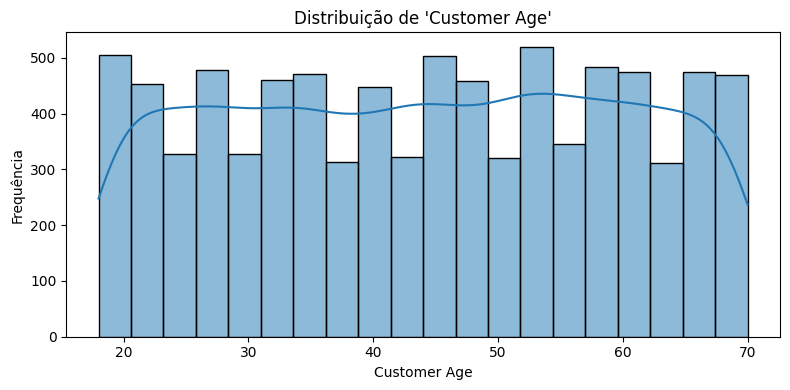


Variável 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64


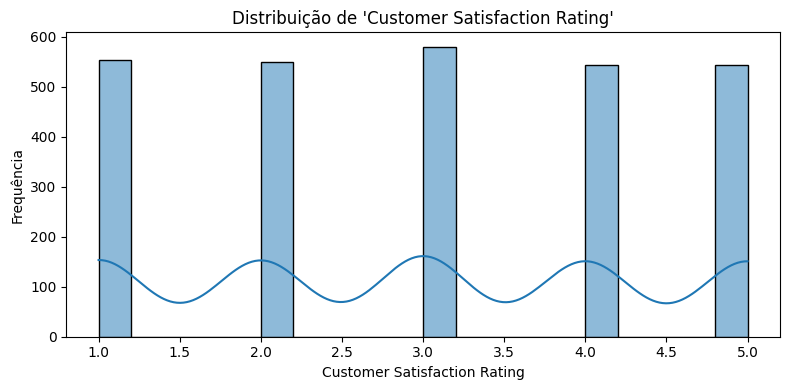

In [ ]:
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating"]

print_formatado("1. Média, mediana, mínimo e máximo:")
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(f"Média  : {df[coluna].mean():.2f}")
    print(f"Mediana: {df[coluna].median():.2f}")
    print(f"Mínimo : {df[coluna].min()}")
    print(f"Máximo : {df[coluna].max()}")

print_formatado("2. Quartis, variância e desvio-padrão:")
for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)
    print(f"\nVariável '{coluna}':")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q2 (50%): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Variância    : {df[coluna].var():.2f}")
    print(f"Desvio-padrão: {df[coluna].std():.2f}")

print_formatado("3. Distribuição dos valores:")
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(df[coluna].describe())

    plt.figure(figsize=(8, 4))
    sns.histplot(df[coluna].dropna(), kde=True, bins=20)
    plt.title(f"Distribuição de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


## Variáveis categóricas



1. Quantidade de categorias:
Ticket Type         5
Ticket Subject     16
Ticket Status       3
Ticket Priority     4
Ticket Channel      4
Customer Gender     3
dtype: int64


2. Frequência absoluta e relativa:

Variável 'Ticket Type' - frequência absoluta:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Variável 'Ticket Type' - frequência relativa (%):
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64


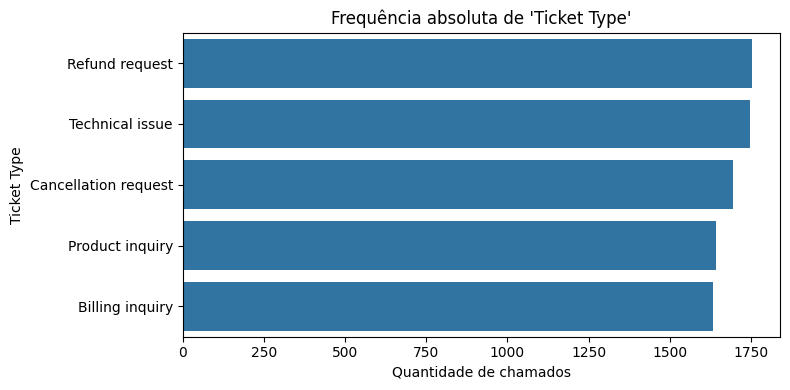


Variável 'Ticket Subject' - frequência absoluta:
Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

Variável 'Ticket Subject' - frequência relativa (%):
Ticket Subject
Refund request              6.80
Software bug                6.78
Product compatibility       6.70
Delivery problem            6.62
Hardware issue              6.46
Battery life                6.40
Network problem             6.36
Installation support        6.26
Product setup               6.25
Payment issue               6.2

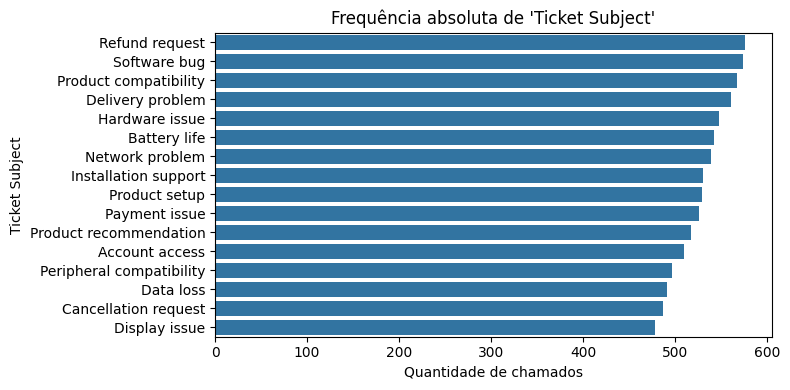


Variável 'Ticket Status' - frequência absoluta:
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Variável 'Ticket Status' - frequência relativa (%):
Ticket Status
Pending Customer Response    34.02
Open                         33.29
Closed                       32.70
Name: proportion, dtype: float64


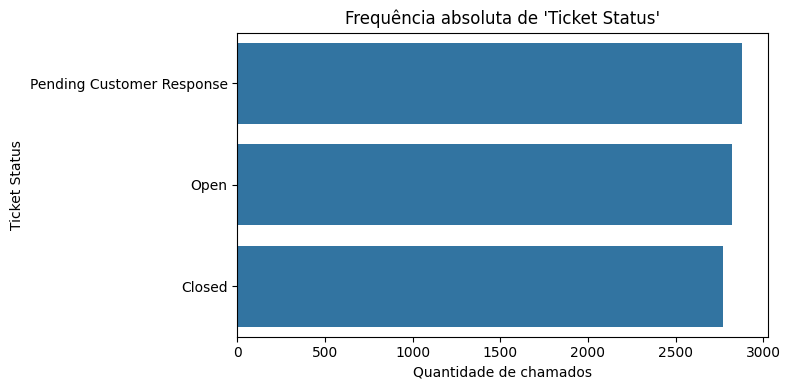


Variável 'Ticket Priority' - frequência absoluta:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Variável 'Ticket Priority' - frequência relativa (%):
Ticket Priority
Medium      25.88
Critical    25.14
High        24.62
Low         24.36
Name: proportion, dtype: float64


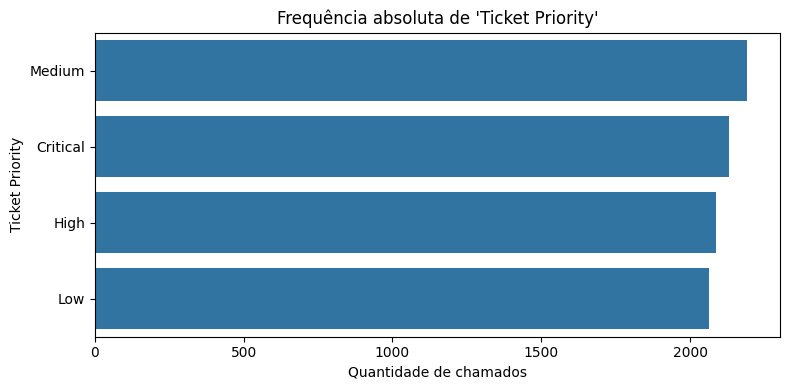


Variável 'Ticket Channel' - frequência absoluta:
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Variável 'Ticket Channel' - frequência relativa (%):
Ticket Channel
Email           25.30
Phone           25.17
Social media    25.04
Chat            24.48
Name: proportion, dtype: float64


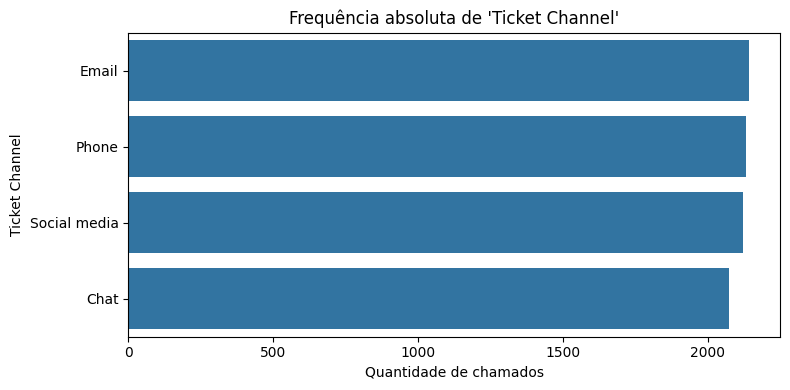


Variável 'Customer Gender' - frequência absoluta:
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Variável 'Customer Gender' - frequência relativa (%):
Customer Gender
Male      34.20
Female    34.09
Other     31.72
Name: proportion, dtype: float64


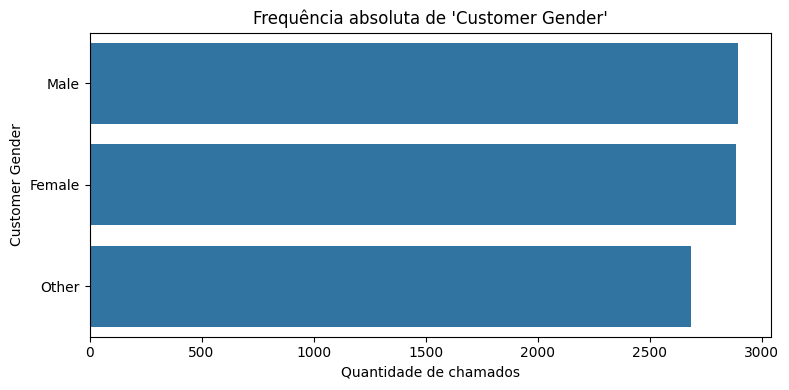



3. Categoria mais frequente:
'Ticket Type': Refund request (1752 chamados, 20.7%)
'Ticket Subject': Refund request (576 chamados, 6.8%)
'Ticket Status': Pending Customer Response (2881 chamados, 34.0%)
'Ticket Priority': Medium (2192 chamados, 25.9%)
'Ticket Channel': Email (2143 chamados, 25.3%)
'Customer Gender': Male (2896 chamados, 34.2%)


In [ ]:
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender"]

print_formatado("1. Quantidade de categorias:")
print(df[colunas_categoricas].nunique())

print_formatado("2. Frequência absoluta e relativa:")
for coluna in colunas_categoricas:
    frequencia_absoluta = df[coluna].value_counts(dropna=False)
    frequencia_relativa = df[coluna].value_counts(normalize=True, dropna=False).round(4) * 100

    print(f"\nVariável '{coluna}' - frequência absoluta:")
    print(frequencia_absoluta)
    print(f"\nVariável '{coluna}' - frequência relativa (%):")
    print(frequencia_relativa.round(2))

    plt.figure(figsize=(8, 4))
    ordem = frequencia_absoluta.index
    sns.barplot(x=frequencia_absoluta.values, y=[str(i) for i in ordem])
    plt.title(f"Frequência absoluta de '{coluna}'")
    plt.xlabel("Quantidade de chamados")
    plt.ylabel(coluna)
    plt.tight_layout()
    plt.show()

print_formatado("3. Categoria mais frequente:")
for coluna in colunas_categoricas:
    categoria_mais_frequente = df[coluna].mode(dropna=False)[0]
    quantidade = df[coluna].value_counts(dropna=False).iloc[0]
    percentual = df[coluna].value_counts(normalize=True, dropna=False).iloc[0] * 100
    print(f"'{coluna}': {categoria_mais_frequente} ({quantidade} chamados, {percentual:.1f}%)")


## Observações - Análise Univariada

**Variáveis numéricas**

- `Customer Age`: distribuição aproximadamente uniforme entre 18 e 70 anos (média ≈ 44, mediana ≈ 44), sem concentração em nenhuma faixa etária específica - coerente com uma base de clientes sem recorte demográfico.
- `Customer Satisfaction Rating`: calculada apenas para os **2.769 chamados fechados**; os valores se distribuem de forma praticamente uniforme entre as notas 1 a 5 (média ≈ 2,99, mediana = 3), sem viés claro para notas altas ou baixas.

**Variáveis categóricas**

- `Ticket Type` (variável-alvo): as 5 categorias são bem balanceadas, entre 19,3% (`Billing inquiry`) e 20,7% (`Refund request`) - não há classe dominante nem classe rara.
- `Ticket Subject`: 16 assuntos com frequências relativamente próximas (entre ~5,6% e ~6,8% cada); `Refund request` e `Software bug` são os mais frequentes.
- `Ticket Status`: praticamente dividido em três partes iguais entre `Pending Customer Response` (34,0%), `Open` (33,3%) e `Closed` (32,7%).
- `Ticket Priority` e `Ticket Channel`: ambas quase uniformemente distribuídas entre suas 4 categorias (~24% a ~26% cada).
- `Customer Gender`: distribuição próxima entre `Male` (34,2%), `Female` (34,1%) e `Other` (31,7%).

De forma geral, praticamente todas as variáveis categóricas deste dataset sintético apresentam distribuição **próxima da uniforme**, o que é um indício de que os dados foram gerados artificialmente por sorteio balanceado entre categorias, e não coletados de um sistema real de atendimento (onde normalmente há categorias desbalanceadas).


# 8. Hipóteses sobre as Intenções dos Usuários

A partir dos padrões observados na Análise Univariada (histogramas e gráficos de barras acima), formulamos as seguintes hipóteses sobre as intenções dos usuários que abrem chamados de suporte:

**Hipótese 1 - Não há uma intenção dominante única.**
Como `Ticket Type` está quase uniformemente distribuído entre as 5 categorias (19,3% a 20,7%), é razoável supor que os usuários que buscam suporte trazem **motivações diversificadas e igualmente frequentes** - problemas técnicos, dúvidas de cobrança, pedidos de cancelamento, dúvidas sobre produto e pedidos de reembolso ocorrem com praticamente a mesma probabilidade. Um sistema de atendimento não pode assumir que a maioria dos chamados será de um único tipo; ele precisa lidar bem com as 5 intenções igualmente.

**Hipótese 2 - Reembolso e falhas de produto são as intenções mais concretas/recorrentes.**
Entre os 16 assuntos (`Ticket Subject`), `Refund request` e `Software bug` são os mais frequentes. Combinado com `Ticket Type`, isso sugere que uma parcela relevante das intenções dos usuários está ligada a **frustração pós-compra** (o produto não funciona como esperado ou o cliente quer o dinheiro de volta), e não apenas a dúvidas genéricas de pré-venda.

**Hipótese 3 - A urgência percebida pelo usuário independe do tipo de problema.**
`Ticket Priority` está distribuída de forma quase uniforme (24,4% a 25,9%) entre `Low`, `Medium`, `High` e `Critical`, sem qualquer categoria dominante. Isso sugere a hipótese de que, na percepção do usuário, **a urgência de um chamado não está fortemente associada a um tipo específico de intenção** - tanto uma dúvida de produto quanto um problema técnico crítico aparecem com prioridades espalhadas por todos os níveis.
